In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE

In [2]:
X_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv")
y_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_train.csv").values.ravel()
X_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv")
y_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_test.csv").values.ravel()

In [3]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)


Resampled training set shape: (800, 8) (800,)


c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [4]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='recall', 
    cv=5, 
    n_jobs=-1)

grid_search.fit(X_train_resampled, y_train_resampled)
print("Best C:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Best C: {'C': 10}
Best CV Recall: 0.7050000000000001


In [6]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC  : {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return acc, prec, rec, f1, auc

In [7]:
lr = LogisticRegression(C=grid_search.best_params_['C'], max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)


Logistic Regression
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1-score : 0.6207
AUC-ROC  : 0.8111

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



(0.7142857142857143,
 0.5806451612903226,
 0.6666666666666666,
 0.6206896551724138,
 np.float64(0.8111111111111111))


Logistic Regression
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1-score : 0.6207
AUC-ROC  : 0.8111

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154


Summary of Results:
                 Model  Accuracy  Precision    Recall  F1-score   AUC-ROC
0  Logistic Regression  0.714286   0.580645  0.666667   0.62069  0.811111


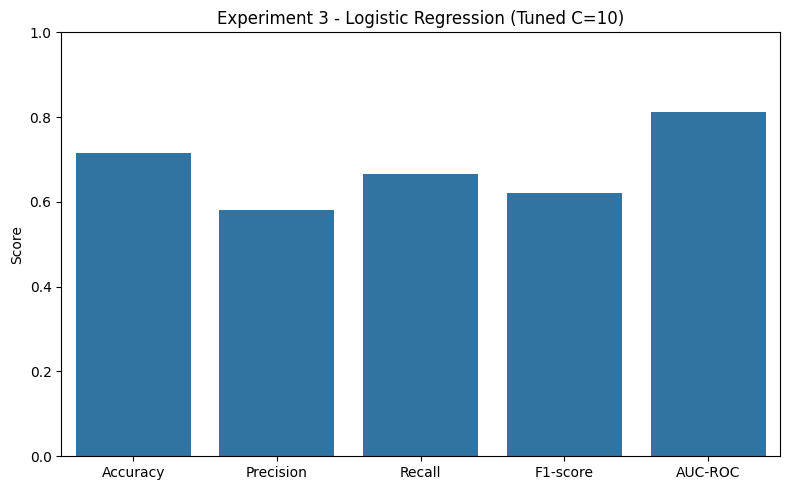

In [14]:
results = []

acc, prec, rec, f1, auc = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "AUC-ROC": auc
})

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]
results_df = pd.DataFrame(results, columns=columns)
print("\nSummary of Results:")
print(results_df)

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]
values = results_df[metrics].values.flatten()

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values)
plt.title("Experiment 3 - Logistic Regression (Tuned C=10)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()